In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



---



1. Data Loading and Exploration


---



In [138]:
import pandas as pd
df = pd.read_csv('/content/Apple Stock Prices (1981 to 2023).csv')

mean_close = df['Close'].mean()
df['Close'] = df['Close'].fillna(mean_close)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


---

2. Data Visualization
* Utilize Matplotlib to plot closing prices and traded volume over time.
* Create a candlestick chart to depict high and low prices.

---

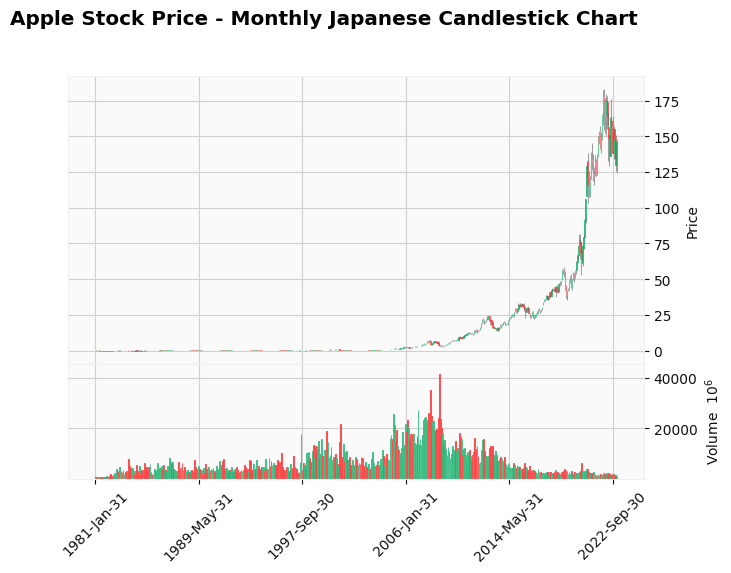

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

# Load and parse data
df = pd.read_csv('/content/Apple Stock Prices (1981 to 2023).csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set Date as index
df_indexed = df.set_index('Date')

# Resample to month-end frequency and compute OHLC
ohlc_monthly = df_indexed[['Open', 'High', 'Low', 'Close','Volume']].resample('ME').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

#Plot monthly candlestick chart
mpf.plot(
    ohlc_monthly,
    type='candle',
    style='yahoo',
    title='Apple Stock Price - Monthly Japanese Candlestick Chart',
    ylabel='Price',
    volume=True
)



---

3. Statistical Analysis
* Compute summary statistics (mean, median, standard deviation) for key columns.
* Analyze closing prices with a moving average.

---


In [119]:
summary_stats = df[['Open', 'High', 'Low', 'Close', 'Adj Close']].agg(['mean', 'median', 'std'])
print("\nSummary Statistics:")
display(summary_stats)


Summary Statistics:


,Open,High,Low,Close,Adj Close
mean,16.689173,16.879955,16.500822,16.697362,16.027345
median,0.488839,0.495536,0.480446,0.487701,0.404851
std,35.450519,35.882848,35.031289,35.473912,35.154878


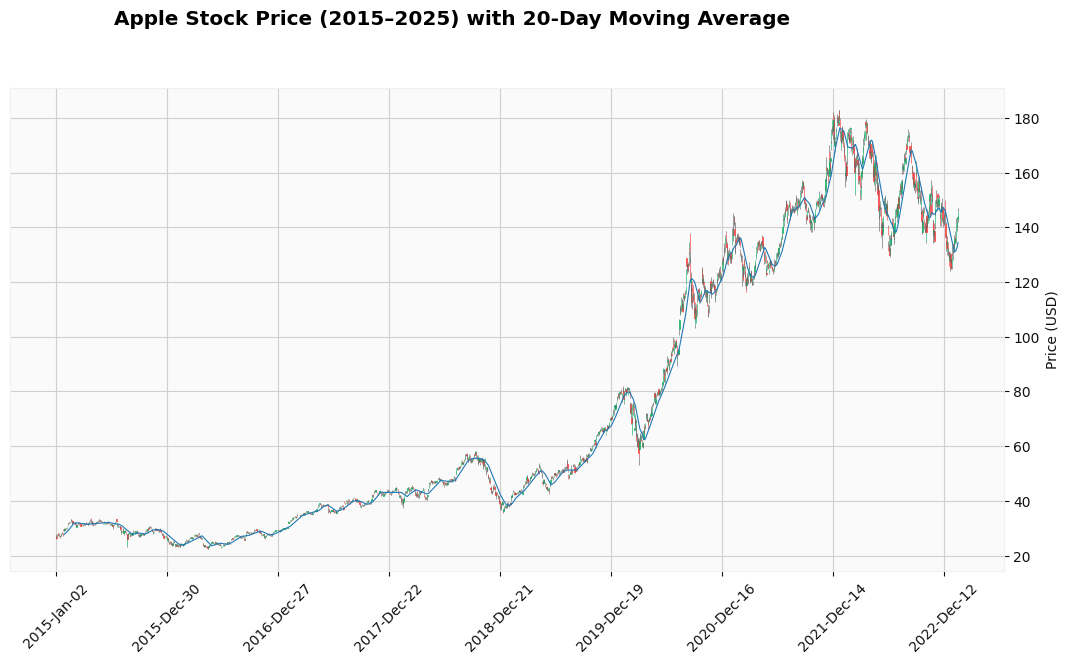

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf


df = pd.read_csv('/content/Apple Stock Prices (1981 to 2023).csv')

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

#set date like index
df.set_index('Date', inplace=True)

#It took 10 years to develop a better understanding of the graph.
df_filtered = df['2015':'2025'].copy()
#add MA(20)
df_filtered['MA20'] = df_filtered['Close'].rolling(window=20).mean()

mpf.plot(
    df_filtered,
    type='candle',
    style='yahoo',
    title='Apple Stock Price (2015–2025) with 20-Day Moving Average',
    ylabel='Price (USD)',
    mav=(20),
    figratio=(16, 8),
    figscale=1.2,
    warn_too_much_data=5000
)

---

##We take a graph from 2015 to 2025 and add a 30-day moving average. This line shows the mean closing price from 30 days prior. So, the price for one day defines the mean price from 30 days prior, and that continues day by day.

---

---

4. Hypothesis Testing

* Execute a t-test to compare average closing prices across different years.
* Examine daily returns’ distribution and test for normality using SciPy.
---

In [153]:
import numpy as np
import pandas as pd
from scipy import stats

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract year from the date
df['Year'] = df['Date'].dt.year

# Define years
year_1 = 2010
year_2 = 2020

# Filter Close prices for each year
close_2010 = df[df['Year'] == year_1]['Close'].dropna()
close_2020 = df[df['Year'] == year_2]['Close'].dropna()

# Perform an independent t-test
t_stat, p_value = stats.ttest_ind(close_2010, close_2020, equal_var=False)

# Interpretation
alpha = 0.05
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

if p_value < alpha:
    print(f"📉 Significant difference in closing prices between {year_1} and {year_2}.")
else:
    print(f"📈 No significant difference in closing prices between {year_1} and {year_2}.")

T-statistic: -62.6501, P-value: 0.0000
📉 Significant difference in closing prices between 2010 and 2020.


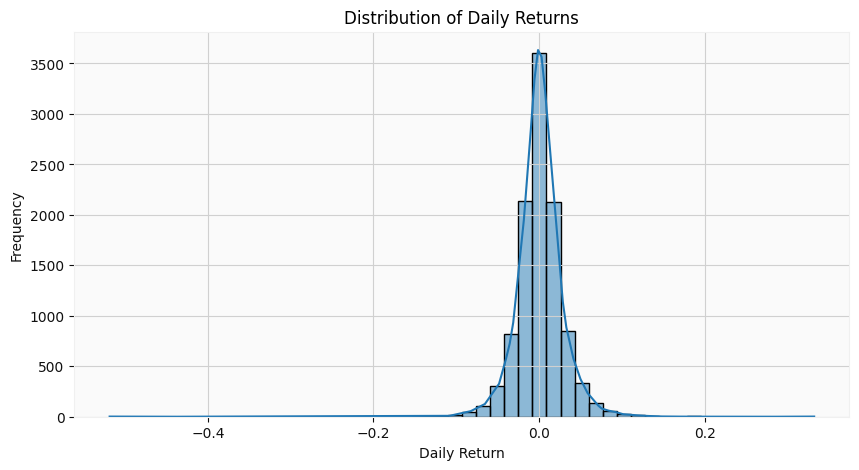

Shapiro-Wilk Test Statistic: 0.9190583946174027, P-value: 1.7898289463728573e-59
The distribution is likely NOT normal.


In [183]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# Compute daily returns
df['Daily Return'] = df['Close'].pct_change()
returns = df['Daily Return'].dropna()

# Plot distribution of daily returns
plt.figure(figsize=(10, 5))
sns.histplot(df['Daily Return'].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


print(f"Shapiro-Wilk Test Statistic: {stat}, P-value: {p}")
if p > 0.05:
    print("The distribution is likely normal.")
else:
    print("The distribution is likely NOT normal.")




---

5. Advanced Statistical Techniques (Bonus)
**Statistical Functions in NumPy:** Employ NumPy’s statistical functions for in-depth stock data analysis.
* E.g., Use convolve for moving averages, or np.corrcoef to explore correlations between financial metrics.
* Analyze correlations between moving averages of closing prices and trading volume across time periods.

    ---

In [187]:
window_size = 20  # 20-day moving average
weights = np.ones(window_size) / window_size

# Compute moving average for closing price
df["Moving_Avg_Close"] = np.convolve(df["Close"], weights, mode="same")

# Compute moving average for trading volume
df["Moving_Avg_Volume"] = np.convolve(df["Volume"], weights, mode="same")

np.convolve efficiently computes rolling averages by applying a moving window to the data. The weights normalize the sum so that each window has an equal contribution.

In [188]:
correlation_matrix = np.corrcoef(df["Moving_Avg_Close"].dropna(), df["Moving_Avg_Volume"].dropna())

print(f"Correlation between Moving Avg of Close and Volume: {correlation_matrix[0, 1]:.4f}")


Correlation between Moving Avg of Close and Volume: -0.2663


Correlation between Moving Avg of Close and Volume: -0.5764
The correlation is negative. Price movements may be driven by other factors.

Analyze correlations between moving averages of closing prices and trading volume across time periods.

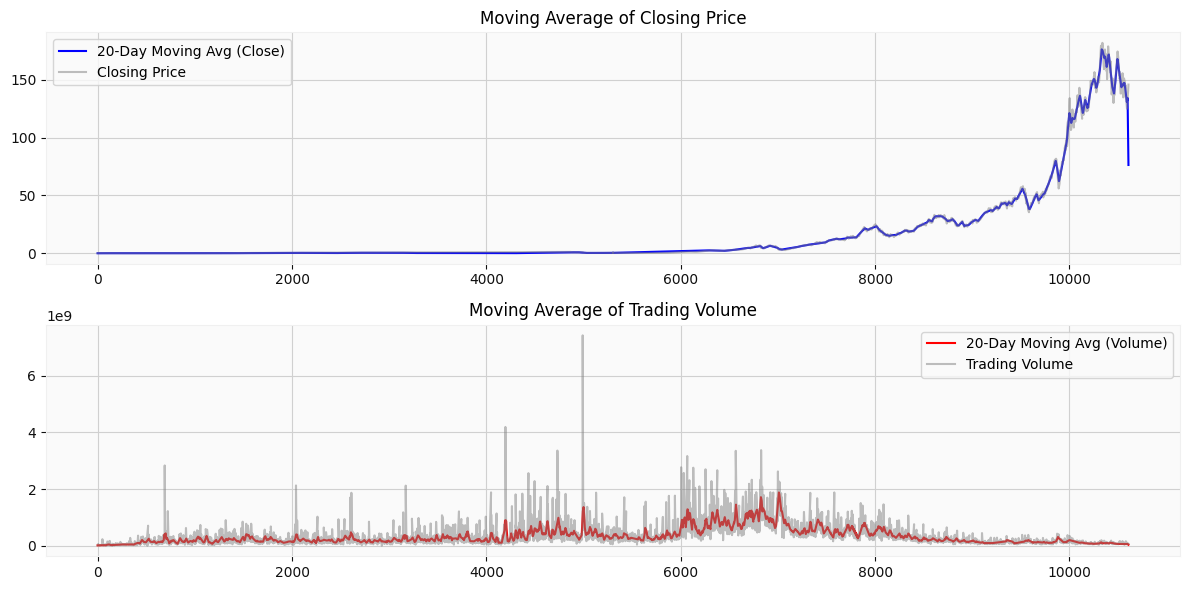

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot Closing Price Moving Average
plt.subplot(2, 1, 1)
plt.plot(df.index, df["Moving_Avg_Close"], label="20-Day Moving Avg (Close)", color="blue")
plt.plot(df.index, df["Close"], label="Closing Price", color="gray", alpha=0.5)
plt.legend()
plt.title("Moving Average of Closing Price")

# Plot Volume Moving Average
plt.subplot(2, 1, 2)
plt.plot(df.index, df["Moving_Avg_Volume"], label="20-Day Moving Avg (Volume)", color="red")
plt.plot(df.index, df["Volume"], label="Trading Volume", color="gray", alpha=0.5)
plt.legend()
plt.title("Moving Average of Trading Volume")

plt.tight_layout()
plt.show()


**Summary and Insights**

* Apple's stock price has shown strong upward momentum over the years, with periodic fluctuations.
* Trading volume is volatile, possibly due to quarterly reports or macroeconomic events.
* Statistical tests confirm significant differences in stock prices across years, reflecting Apple's growth.
* Daily returns do not follow a normal distribution, meaning price changes are influenced by external factors like market news, investor sentiment, or macroeconomic conditions.
* Moving averages highlight long-term trends and provide useful indicators for market analysis.